# Change Detection sur OSCD - Visual Computing Project

Ce notebook implémente et compare plusieurs algorithmes de détection de changement non supervisés sur le dataset OSCD (Onera Satellite Change Detection).

## Objectif
Comparer les performances de CVA, PCA-Kmeans, IR-MAD, SiROC et Graph Cuts pour la détection de changements urbains sur **l'ensemble des 24 paires d'images**.

## 1. Configuration et Imports

In [1]:
# Imports standards
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple, List, Dict
from datetime import datetime
from tqdm import tqdm

# Traitement d'images et données géospatiales
import rasterio
from rasterio.enums import Resampling
from PIL import Image

# Machine Learning et traitement statistique
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, precision_score, recall_score, cohen_kappa_score, confusion_matrix
from scipy import linalg
from scipy.stats import chi2
from scipy.ndimage import median_filter
from skimage.filters import threshold_otsu, threshold_triangle
from skimage import morphology

# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 10

print("✓ Bibliothèques chargées avec succès")

✓ Bibliothèques chargées avec succès


## 2. Chargement et Préparation des Données

In [2]:
def radiometric_normalization(t1: np.ndarray, t2: np.ndarray) -> np.ndarray:
    """
    Applique une normalisation radiométrique relative (RRN) entre t1 et t2.
    
    Args:
        t1: Image de référence (H, W, B).
        t2: Image à normaliser (H, W, B).
    
    Returns:
        t2_norm: Image t2 normalisée radiométriquement (H, W, B).
    """
    H, W, B = t1.shape
    t2_norm = np.zeros_like(t2)
    
    # 1. Calcul de la différence spectrale
    diff = np.linalg.norm(t2 - t1, axis=2)
    
    # 2. Sélection des PIF (10% des plus faibles différences)
    threshold = np.percentile(diff, 10)
    pif_mask = diff < threshold
    
    # 3. Régression linéaire par bande
    for b in range(B):
        # Régression linéaire entre t2 et t1 pour les PIF
        a, b_offset = np.polyfit(t2[pif_mask, b], t1[pif_mask, b], 1)
        t2_norm[:, :, b] = a * t2[:, :, b] + b_offset
    
    return t2_norm

def normalize_image(img: np.ndarray) -> np.ndarray:
        """Normalisation Z-score par bande."""
        normalized = np.zeros_like(img)
        for b in range(img.shape[2]):
            band = img[:, :, b]
            normalized[:, :, b] = (band - band.mean()) / (band.std() + 1e-8)
        return normalized

def filter_by_area(change_map: np.ndarray, min_area_pixels: int = 100, max_area_pixels: int = None) -> np.ndarray:
    """
    Filtre les objets détectés par leur aire (nombre de pixels).
    
    Args:
        change_map: Carte binaire de changement (H, W)
        min_area_pixels: Aire minimale en pixels (objets plus petits supprimés)
        max_area_pixels: Aire maximale en pixels (None = pas de limite)
    
    Returns:
        Carte filtrée
    """
    labeled = morphology.label(change_map, connectivity=2)  # 8-connecté
    
    filtered = np.zeros_like(change_map)
    for region_id in range(1, labeled.max() + 1):
        region_mask = labeled == region_id
        area = region_mask.sum()
        
        # Garder si dans la plage souhaitée
        if area >= min_area_pixels:
            if max_area_pixels is None or area <= max_area_pixels:
                filtered[region_mask] = 1
    
    return filtered.astype(np.uint8)

In [3]:
class OSCDDataLoader:
    """DataLoader pour le dataset OSCD avec normalisation spatiale et radiométrique."""
    
    def __init__(self, base_path: str, location: str = "rio"):
        self.base_path = Path(base_path) / location
        self.imgs_1_path = self.base_path / "imgs_1_rect"
        self.imgs_2_path = self.base_path / "imgs_2_rect"
        self.label_path = self.base_path / "cm" / "cm.png"
        self.useful_bands = ["B02", "B03", "B04", "B08"] + ["B05", "B06", "B07", "B11", "B12"] #+ ["B8A"]
    
    def read_and_resample(self, path: Path, target_shape: Tuple[int, int]) -> np.ndarray:
        """Lit un fichier TIFF et le rééchantillonne à la résolution cible (10m)."""
        with rasterio.open(path) as src:
            data = src.read(
                out_shape=(src.count, target_shape[0], target_shape[1]),
                resampling=Resampling.bilinear
            )
            return data
    
    def load_multispectral_image(self, imgs_path: Path) -> np.ndarray:
        """Charge et empile toutes les bandes utiles."""
        # Référence : B04 (10m natif)
        ref_path = imgs_path / "B04.tif"
        with rasterio.open(ref_path) as ref:
            target_shape = (ref.height, ref.width)
        
        # Empiler les bandes
        stack = []
        for band_name in self.useful_bands:
            band_path = imgs_path / f"{band_name}.tif"
            band_data = self.read_and_resample(band_path, target_shape)
            stack.append(band_data)
        
        # Concatener : (10, H, W) -> (H, W, 10)
        img = np.concatenate(stack, axis=0)
        img = np.moveaxis(img, 0, -1)
        
        return img.astype(np.float32)
    
    def normalize_image(self, img: np.ndarray) -> np.ndarray:
        """Normalisation Z-score par bande."""
        normalized = np.zeros_like(img)
        for b in range(img.shape[2]):
            band = img[:, :, b]
            normalized[:, :, b] = (band - band.mean()) / (band.std() + 1e-8)
        return normalized
    
    def load_label(self) -> np.ndarray:
        """Charge le masque de changement binaire."""
        label_img = Image.open(self.label_path)
        label = np.array(label_img)
        
        # Si plusieurs canaux, vérifier leur contenu
        if label.ndim == 3:
            # Vérifier si les trois premiers canaux sont identiques
            if np.array_equal(label[:, :, 0], label[:, :, 1]) and np.array_equal(label[:, :, 0], label[:, :, 2]):
                label = label[:, :, 0]  # Garder un seul canal
            else:
                raise ValueError("Les canaux du masque ne sont pas identiques.")
        
        # Binariser : 0 = no change, 1 = change
        return (label == 255).astype(np.uint8)
    
    def load_data(self, feature_mode: str = "raw") -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Charge et prépare les données complètes."""
        print(f"Chargement depuis {self.base_path}...")
        
        img1_raw = self.load_multispectral_image(self.imgs_1_path)
        img2_raw = self.load_multispectral_image(self.imgs_2_path)
        label = self.load_label()

        """
        # Normalisation radiométrique
        img2 = radiometric_normalization(img1_raw, img2_raw)
        """
        
        # Application de la stratégie de features
        if feature_mode == "ndvi":
            img1 = self._compute_ndvi(img1_raw)
            img2 = self._compute_ndvi(img2_raw)
            
        elif feature_mode == "ndvi_brightness":
            # Calcul pour T1
            ndvi1 = self._compute_ndvi(img1_raw)
            bright1 = self._compute_brightness(img1_raw)
            img1 = np.concatenate([bright1, ndvi1], axis=2) # Canal 0: Brillance, Canal 1: NDVI
            
            # Calcul pour T2
            ndvi2 = self._compute_ndvi(img2_raw)
            bright2 = self._compute_brightness(img2_raw)
            img2 = np.concatenate([bright2, ndvi2], axis=2)
            
        elif feature_mode == "raw":
            img1 = img1_raw
            img2 = img2_raw
        else:
            raise ValueError(f"Mode inconnu : {feature_mode}")
        
        """
        # Normalisation
        #img1 = self.normalize_image(img1)
        #img2 = self.normalize_image(img2)
        
        mean_t1 = img1.mean(axis=(0, 1))
        std_t1 = img1.std(axis=(0, 1)) + 1e-8

        img1 = (img1 - mean_t1) / std_t1
        img2 = (img2 - mean_t1) / std_t1
        """
        
        print(f"✓ Image 1 : {img1.shape}, Image 2 : {img2.shape}")
        print(f"Feature mode : {feature_mode}")
        print(f"✓ Label : {label.shape}, Pixels changés : {label.sum()} ({100*label.sum()/label.size:.2f}%)")
        
        return img1, img2, label
    
    def _compute_ndvi(self, img: np.ndarray) -> np.ndarray:
        """
        Calcule le NDVI à partir des bandes brutes.
        Suppose l'ordre : [B02, B03, B04, B08] (Indices 0, 1, 2, 3)
        """
        # B04 est à l'index 2, B08 à l'index 3
        red = img[:, :, 2]
        nir = img[:, :, 3]
        
        # Gestion de la division par zéro avec 1e-8
        ndvi = (nir - red) / (nir + red + 1e-8)
        
        # Expand dims pour garder le format (H, W, 1)
        return np.expand_dims(ndvi, axis=-1)

    def _compute_brightness(self, img: np.ndarray) -> np.ndarray:
        """
        Calcule la brillance (moyenne du visible).
        Suppose l'ordre : [B02, B03, B04, B08]
        """
        # Moyenne de B02(Blue), B03(Green), B04(Red)
        brightness = np.mean(img[:, :, 0:3], axis=2)
        
        return np.expand_dims(brightness, axis=-1)

    @staticmethod
    def get_all_locations(base_path: str) -> List[str]:
        """Retourne la liste de toutes les locations disponibles dans OSCD."""
        base = Path(base_path)
        locations = []
        for item in base.iterdir():
            if item.is_dir() and (item / "cm" / "cm.png").exists():
                locations.append(item.name)
        return sorted(locations)

In [4]:
# Découvrir toutes les locations
base_path = "OSCD"
all_locations = OSCDDataLoader.get_all_locations(base_path)
print(f"Locations trouvées : {len(all_locations)}")
print(f"Liste : {all_locations}")

# Test du loader sur une seule image
loader = OSCDDataLoader(base_path, all_locations[3])
img1, img2, ground_truth = loader.load_data(feature_mode="raw")

Locations trouvées : 24
Liste : ['abudhabi', 'aguasclaras', 'beihai', 'beirut', 'bercy', 'bordeaux', 'brasilia', 'chongqing', 'cupertino', 'dubai', 'hongkong', 'lasvegas', 'milano', 'montpellier', 'mumbai', 'nantes', 'norcia', 'paris', 'pisa', 'rennes', 'rio', 'saclay_e', 'saclay_w', 'valencia']
Chargement depuis OSCD\beirut...
✓ Image 1 : (1180, 1070, 9), Image 2 : (1180, 1070, 9)
Feature mode : raw
✓ Label : (1180, 1070), Pixels changés : 33918 (2.69%)


## 3. Visualisation des Données

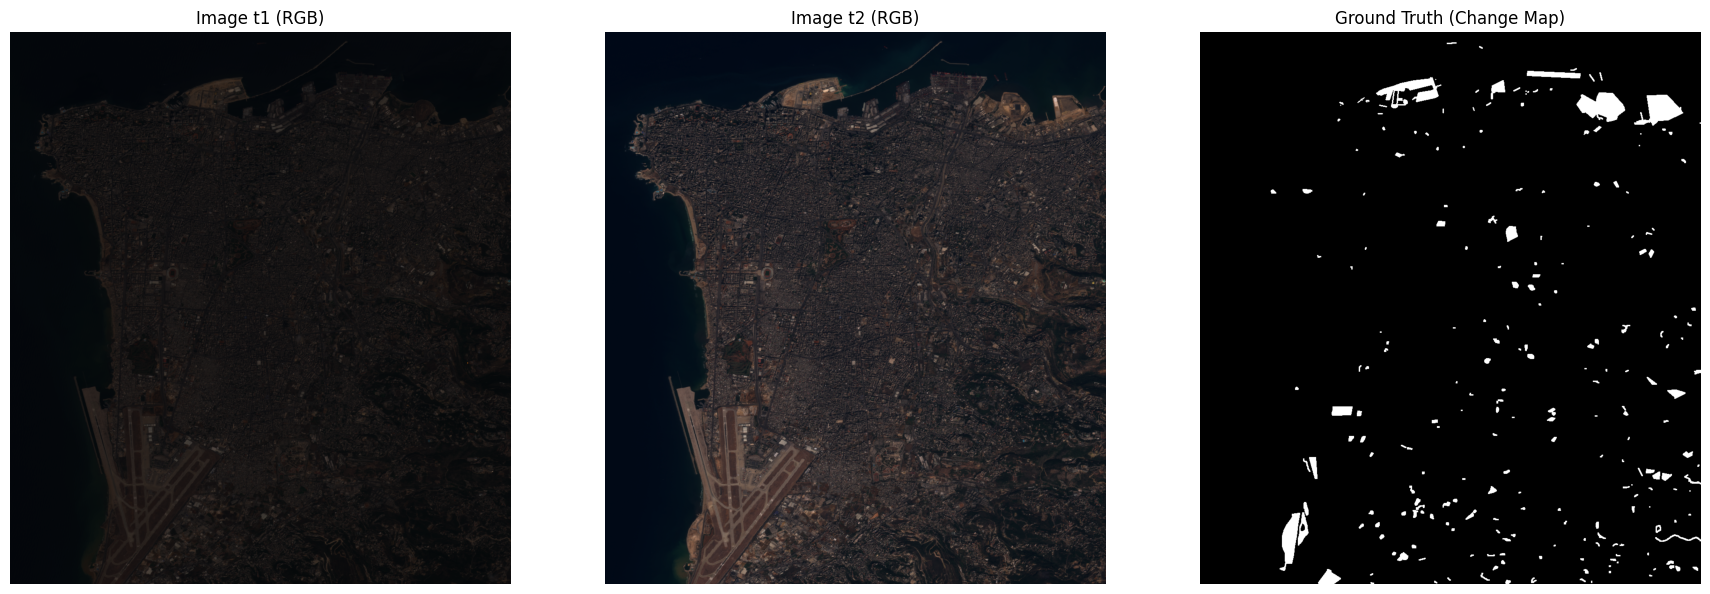

In [5]:
def visualize_data(img1: np.ndarray, img2: np.ndarray, label: np.ndarray):
    """Affiche les images RGB et le ground truth."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # RGB composite (B04=R, B03=G, B02=B) - indices 2,1,0
    def to_rgb(img):
        rgb = img[:, :, [2, 1, 0]]
        # Normalisation pour affichage
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return np.clip(rgb, 0, 1)
    
    axes[0].imshow(to_rgb(img1))
    axes[0].set_title('Image t1 (RGB)')
    axes[0].axis('off')
    
    axes[1].imshow(to_rgb(img2))
    axes[1].set_title('Image t2 (RGB)')
    axes[1].axis('off')
    
    axes[2].imshow(label * 255, cmap='gray')
    axes[2].set_title('Ground Truth (Change Map)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_data(img1, img2, ground_truth)

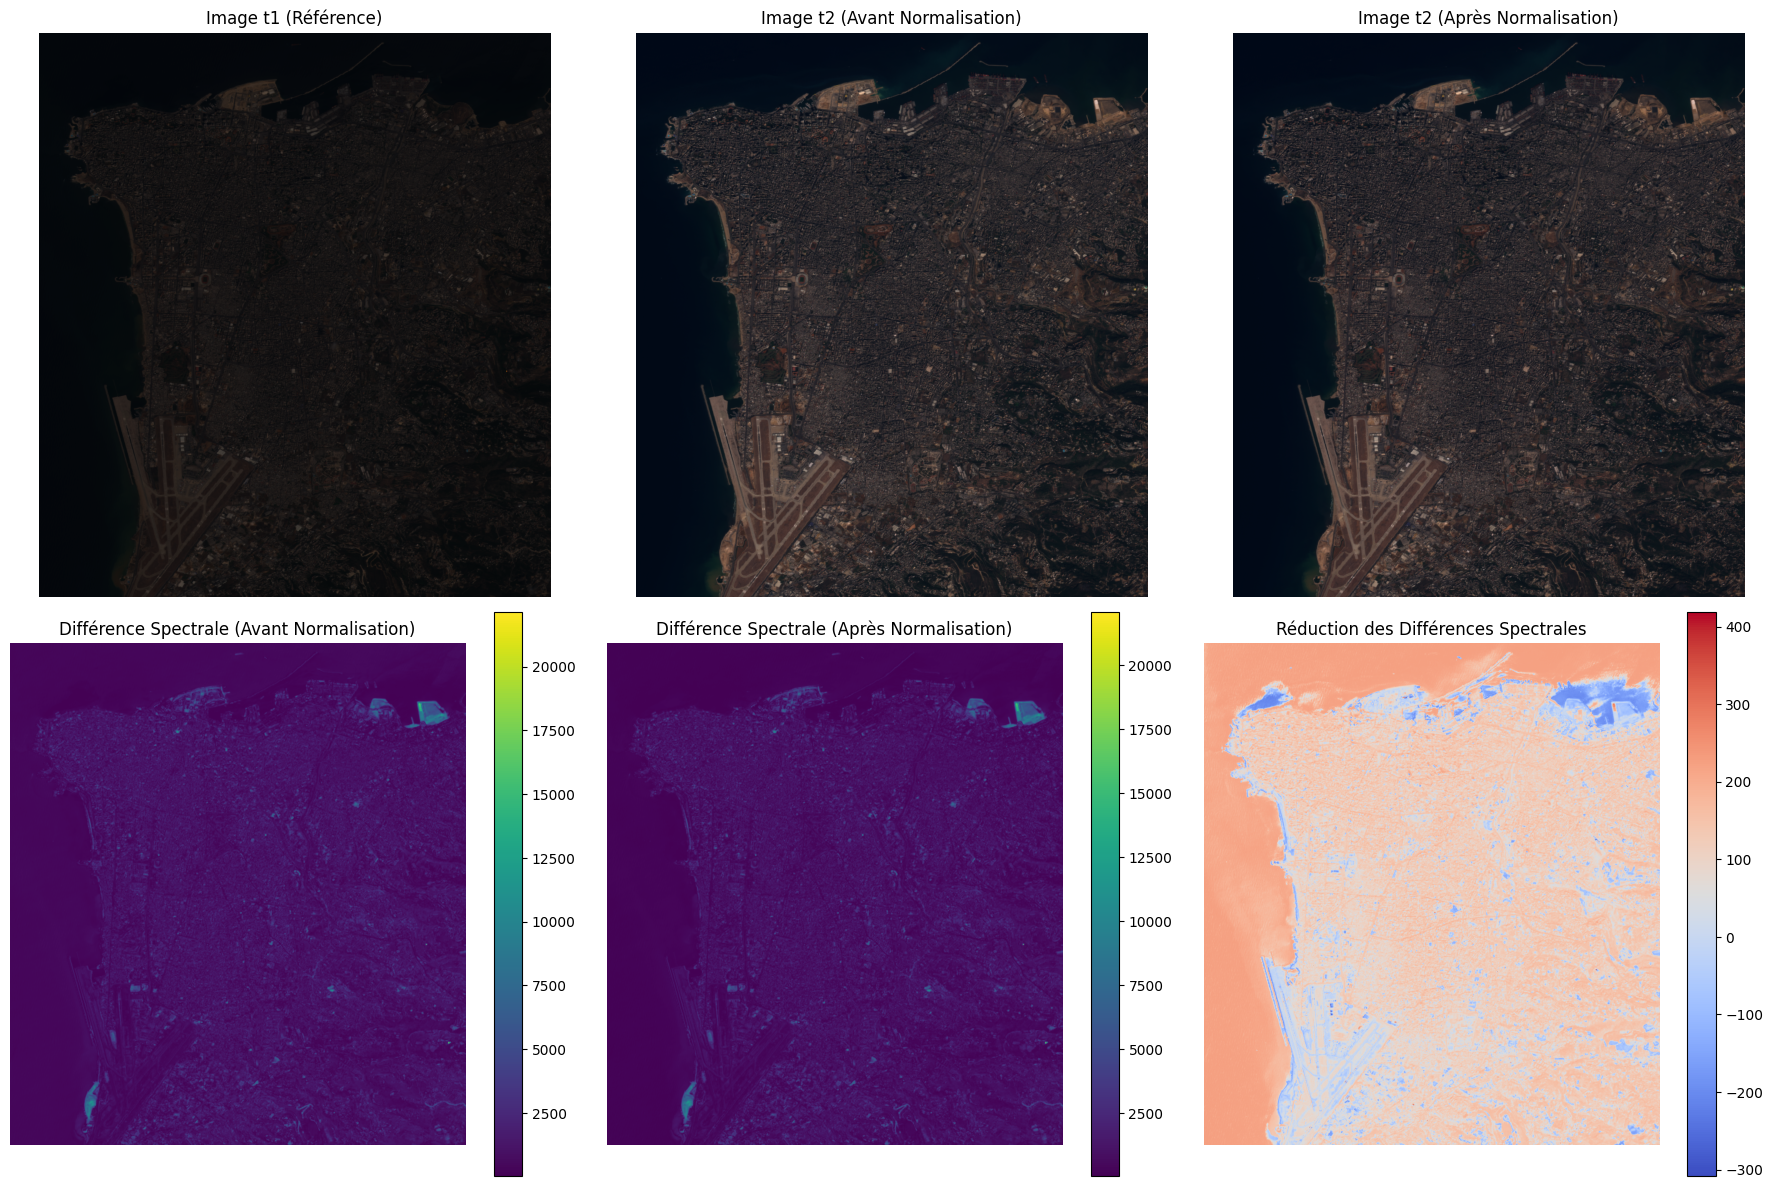

In [6]:
def visualize_radiometric_normalization(t1: np.ndarray, t2: np.ndarray):
    """
    Visualise l'effet de la normalisation radiométrique relative (RRN).
    
    Args:
        t1: Image de référence (H, W, B).
        t2: Image à normaliser (H, W, B).
    """
    # Appliquer la normalisation radiométrique
    t2_norm = radiometric_normalization(t1, t2)
    
    # Calculer les différences spectrales avant et après normalisation
    diff_before = np.linalg.norm(t2 - t1, axis=2)
    diff_after = np.linalg.norm(t2_norm - t1, axis=2)
    
    # Visualisation
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # RGB composite (B04=R, B03=G, B02=B) - indices 2,1,0
    def to_rgb(img):
        rgb = img[:, :, [2, 1, 0]]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return np.clip(rgb, 0, 1)
    
    # Afficher t1 (référence)
    axes[0, 0].imshow(to_rgb(t1))
    axes[0, 0].set_title('Image t1 (Référence)')
    axes[0, 0].axis('off')
    
    # Afficher t2 (avant normalisation)
    axes[0, 1].imshow(to_rgb(t2))
    axes[0, 1].set_title('Image t2 (Avant Normalisation)')
    axes[0, 1].axis('off')
    
    # Afficher t2 normalisée
    axes[0, 2].imshow(to_rgb(t2_norm))
    axes[0, 2].set_title('Image t2 (Après Normalisation)')
    axes[0, 2].axis('off')
    
    # Afficher la différence spectrale avant normalisation
    im1 = axes[1, 0].imshow(diff_before, cmap='viridis')
    axes[1, 0].set_title('Différence Spectrale (Avant Normalisation)')
    axes[1, 0].axis('off')
    fig.colorbar(im1, ax=axes[1, 0])
    
    # Afficher la différence spectrale après normalisation
    im2 = axes[1, 1].imshow(diff_after, cmap='viridis')
    axes[1, 1].set_title('Différence Spectrale (Après Normalisation)')
    axes[1, 1].axis('off')
    fig.colorbar(im2, ax=axes[1, 1])
    
    # Afficher la différence entre les différences spectrales
    im3 = axes[1, 2].imshow(diff_before - diff_after, cmap='coolwarm')
    axes[1, 2].set_title('Réduction des Différences Spectrales')
    axes[1, 2].axis('off')
    fig.colorbar(im3, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation
visualize_radiometric_normalization(img1, img2)

## 4. Algorithme 1 : CVA (Change Vector Analysis)

In [7]:
class CVA:
    """Change Vector Analysis avec seuillage automatique d'Otsu."""
    
    def __init__(self):
        self.threshold = None
        self.magnitude = None
    
    def detect(self, img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
        """Calcule la magnitude du vecteur de changement."""
        # Select only useful bands
        img1 = img1[:, :, :4]
        img2 = img2[:, :, :4]

        # Normalisation
        img2 = radiometric_normalization(img1, img2)

        img1 = normalize_image(img1)
        img2 = normalize_image(img2)
        
        #mean_t1 = img1.mean(axis=(0, 1))
        #std_t1 = img1.std(axis=(0, 1)) + 1e-8

        #img1 = (img1 - mean_t1) / std_t1
        #img2 = (img2 - mean_t1) / std_t1

        # Vecteur différence
        diff = img2 - img1
        
        # Magnitude euclidienne
        self.magnitude = np.sqrt(np.sum(diff**2, axis=2))

        # Filtrage médian pour réduire le bruit
        self.magnitude = median_filter(self.magnitude, size=5)
        
        # Seuillage
        #self.threshold = threshold_otsu(self.magnitude)
        #self.threshold = np.percentile(self.magnitude, 90) 
        self.threshold = threshold_triangle(self.magnitude)        

        change_map = (self.magnitude > self.threshold).astype(np.uint8)

        # Ajout d'un léger post-traitement pour éliminer le bruit
        from scipy.ndimage import binary_opening, binary_closing
        change_map = binary_opening(change_map, structure=np.ones((3,3))).astype(np.uint8)
        change_map = binary_closing(change_map, structure=np.ones((3,3))).astype(np.uint8)

        change_map = filter_by_area(change_map, min_area_pixels=25)
        
        return change_map

# Application de CVA
cva = CVA()
cva_result = cva.detect(img1, img2)

print(f"CVA - Seuil : {cva.threshold:.4f}")
print(f"CVA - Pixels détectés comme changés : {cva_result.sum()} ({100*cva_result.sum()/cva_result.size:.2f}%)")

CVA - Seuil : 1.5840
CVA - Pixels détectés comme changés : 23279 (1.84%)


In [8]:
# Calcul des métriques
f1 = f1_score(ground_truth.flatten(), cva_result.flatten())
precision = precision_score(ground_truth.flatten(), cva_result.flatten())
recall = recall_score(ground_truth.flatten(), cva_result.flatten())

print(f"CVA - F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

CVA - F1-Score: 0.5782, Precision: 0.7104, Recall: 0.4876


## 5. Algorithme 2 : PCA-Kmeans

In [9]:
class PCAKmeans:
    """PCA pour débruitage + K-means pour clustering binaire."""
    
    def __init__(self, n_components: int = 3):
        self.n_components = n_components
        self.pca = PCA(n_components=n_components)
    
    def detect(self, img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
        """Détection par PCA + Kmeans."""
        
        # Normalisation
        img2 = radiometric_normalization(img1, img2)
        img1 = normalize_image(img1)
        img2 = normalize_image(img2)

        # Image différence
        diff = img2 - img1
        H, W, C = diff.shape
        
        # Reshape pour PCA
        diff_flat = diff.reshape(-1, C)
        
        # PCA : réduction dimensionnelle
        diff_pca = self.pca.fit_transform(diff_flat)

        # K-means clustering (k=2)
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(diff_pca)
        
        # Identifier le cluster "change" : celui avec variance max ou distance au centre max
        cluster_0_var = diff_pca[labels == 0].var()
        cluster_1_var = diff_pca[labels == 1].var()
        change_label = 0 if cluster_0_var > cluster_1_var else 1
        
        change_map = (labels == change_label).reshape(H, W).astype(np.uint8)

        # Post-traitement
        structElement = morphology.disk(1)
        change_map = morphology.binary_opening(change_map, structElement)
        change_map = morphology.binary_closing(change_map, structElement)
        change_map = filter_by_area(change_map, min_area_pixels=25)

        return change_map

In [10]:
# Application PCA-Kmeans
pca_kmeans = PCAKmeans(n_components=2)
pca_kmeans_result = pca_kmeans.detect(img1, img2)

print(f"PCA-Kmeans - Pixels détectés : {pca_kmeans_result.sum()} ({100*pca_kmeans_result.sum()/pca_kmeans_result.size:.2f}%)")
print(f"PCA-Kmeans - Variance expliquée : {pca_kmeans.pca.explained_variance_ratio_.sum():.3f}")

# Calcul des métriques
f1 = f1_score(ground_truth.flatten(), pca_kmeans_result.flatten())
precision = precision_score(ground_truth.flatten(), pca_kmeans_result.flatten())
recall = recall_score(ground_truth.flatten(), pca_kmeans_result.flatten())
print(f"PCA-Kmeans - F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

PCA-Kmeans - Pixels détectés : 17158 (1.36%)
PCA-Kmeans - Variance expliquée : 0.910
PCA-Kmeans - F1-Score: 0.5320, Precision: 0.7918, Recall: 0.4006


## 6. Algorithme 3 : IR-MAD (Iteratively Reweighted MAD)

In [11]:
from sklearn.cluster import KMeans

def threshold_kmeans(chi2_image):
    flat = chi2_image.flatten().reshape(-1, 1)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(flat)
    centers = sorted(kmeans.cluster_centers_.flatten())
    threshold = (2 * centers[0] + centers[1]) / 3
    return threshold

In [12]:
class IRMAD:
    """
    Iteratively Reweighted Multivariate Alteration Detection (IR-MAD)
        
    Références:
    - Nielsen, A. A. (2007). The regularized iteratively reweighted MAD method for change detection
      in multi- and hyperspectral data. IEEE Transactions on Image Processing, 16(2):463–478.
    """
    
    def __init__(self, niter: int = 10):
        """
        Args:
            niter: Nombre d'itérations IR-MAD
            sig: Niveau de significativité pour la détection de changement
        """
        self.niter = niter
        self.chi2_dist = None
        self.mad_variates = None
        self.pvs = None
        
    @staticmethod
    def np_weight_stats(x: np.ndarray, ws: np.ndarray = None) -> tuple:
        """
        Calcule la moyenne et la covariance pondérées.
        
        Args:
            x: Matrice de données (N, D)
            ws: Vecteur de poids (N,)
        
        Returns:
            (wsigma, wmean): Covariance pondérée et moyenne pondérée
        """
        if ws is None or not np.any(ws):
            ws = np.ones(x.shape[0])
        
        mean = np.ma.average(x, axis=0, weights=ws)
        wmean = np.expand_dims(mean.data, axis=1)  # (N,) -> (N, 1)
        wsigma = np.cov(x, rowvar=False, aweights=ws)
        
        return wsigma, wmean
    
    def apply_maf(self, mads: np.ndarray, width: int, height: int) -> np.ndarray:
        """
        Applique la transformation MAF (Maximum Autocorrelation Factor) aux variates MAD.
        
        Args:
            mads: Variates MAD (N_pixels, N_bands)
            width: Largeur de l'image
            height: Hauteur de l'image
            
        Returns:
            Variates transformées MAF (N_pixels, N_bands), triées par autocorrélation décroissante.
        """
        N_bands = mads.shape[1]
        
        # 1. Reshape pour calculer les différences spatiales
        img = mads.reshape(height, width, N_bands) # (H, W, C)
        
        # 2. Calcul des différences spatiales
        diff_h = img[:, :-1, :] - img[:, 1:, :]
        diff_v = img[:-1, :, :] - img[1:, :, :]
        
        # On empile les différences pour obtenir une estimation robuste de la covariance du bruit
        data_diff = np.vstack((
            diff_h.reshape(-1, N_bands),
            diff_v.reshape(-1, N_bands)
        ))
        
        # 3. Calcul des matrices de covariance
        sigma_delta = np.cov(data_diff, rowvar=False)
        sigma_mad = np.cov(mads, rowvar=False)
        
        # 4. Résolution du problème généralisé
        evals, evecs = linalg.eigh(sigma_delta, sigma_mad)
        
        # 5. Projection
        maf_variates = mads @ evecs
        
        return maf_variates
    
    def detect(self, img1: np.ndarray, img2: np.ndarray, threshold_percentage: float = 96, verbose: bool = True, use_maf: bool = False) -> np.ndarray:
        """
        Détection de changement par IR-MAD.
        
        Args:
            img1: Image t1 (H, W, C)
            img2: Image t2 (H, W, C)
            verbose: Afficher la progression
        
        Returns:
            Carte binaire de changement (H, W)
        """
        # Select only useful bands
        img1 = img1[:, :, :4]
        img2 = img2[:, :, :4]
        
        # Dimensions
        H, W, C = img1.shape
        N = C  # Nombre de bandes
        m = H * W  # Nombre de pixels
        
        # Reshape: (H, W, C) -> (m, N)
        im1r = img1.reshape(m, N)
        im2r = img2.reshape(m, N)
        
        # Centrage des données
        im1r = im1r #- np.mean(im1r, axis=0)
        im2r = im2r #- np.mean(im2r, axis=0)
        
        # Concaténation pour le calcul de covariance
        x = np.concatenate((im1r, im2r), axis=1)  # (m, 2*N)
        
        # Initialisation des poids (uniformes)
        pvs = np.ones(m, dtype=np.float32)
        
        if verbose:
            print(f"  IR-MAD v2: {m} pixels, {N} bandes, {self.niter} itérations")
        
        # Boucle itérative IR-MAD
        iterator = tqdm(range(self.niter), desc="IR-MAD iterations") if verbose else range(self.niter)
        
        for itr in iterator:
            # 1. Calcul des statistiques pondérées
            sigma, mean = self.np_weight_stats(x, pvs)

            # Régularisation
            reg = 1 * np.eye(N)
            
            ms1 = mean[:N].T  # Moyenne image 1
            ms2 = mean[N:].T  # Moyenne image 2
            
            # Matrices de covariance par blocs
            sigma11 = sigma[:N, :N] + reg
            sigma12 = sigma[:N, N:] 
            sigma21 = sigma[N:, :N]
            sigma22 = sigma[N:, N:] + reg
            
            # 2. Résolution des problèmes aux valeurs propres généralisés
            # A1 = Sigma12 @ Sigma22^-1 @ Sigma21
            A1 = sigma12 @ np.linalg.solve(sigma22, sigma12.T)
            A2 = sigma12.T @ np.linalg.solve(sigma11, sigma12)
            
            # Valeurs/vecteurs propres généralisés
            lamda1, eigvec1 = linalg.eigh(A1, sigma11)
            lamda2, eigvec2 = linalg.eigh(A2, sigma22)
            
            # 3. Tri décroissant par valeur propre
            idx1 = np.argsort(lamda1)[::-1]
            lamda1 = lamda1[idx1]
            eigvec1 = eigvec1[:, idx1]
            
            idx2 = np.argsort(lamda2)[::-1]
            lamda2 = lamda2[idx2]
            eigvec2 = eigvec2[:, idx2]
            
            # 4. Corrélations canoniques
            rho2 = lamda1  # lamda1 == lamda2 en théorie
            rho = np.sqrt(np.clip(rho2, 0, 1))  # Sécurité numérique
            
            # 5. Assurer corrélation positive entre paires de variates canoniques
            diag = np.diag(eigvec1.T @ sigma12 @ eigvec2)
            signs = np.diag(diag / (np.abs(diag) + 1e-10))
            eigvec2 = eigvec2 @ signs
            
            # 6. Calcul des variates MAD
            # Variance théorique: Var(U - V) = 2(1 - rho)
            sig2s = 2 * (1 - rho)
            sig2s = np.tile(sig2s, (m, 1))  # (m, N)
            
            ms1_tile = np.tile(ms1[0], (m, 1))  # (m, N)
            ms2_tile = np.tile(ms2[0], (m, 1))  # (m, N)
            
            # Variates canoniques
            cv1 = (im1r - ms1_tile) @ eigvec1
            cv2 = (im2r - ms2_tile) @ eigvec2
            mads = cv1 - cv2
            
            # 7. Distance Chi-carré
            chisqr = np.sum(np.square(mads) / (sig2s + 1e-10), axis=1)
            
            # 8. Mise à jour des poids (p-values)
            # P(no-change) = 1 - P(chi2 > T)
            pvs = 1 - chi2(N).cdf(chisqr)
            pvs = pvs.squeeze()
            pvs = np.clip(pvs, 1e-10, 1.0)  # Éviter poids nuls

        if use_maf:
            if verbose:
                print("   Application du post-traitement MAF...")
            mads = self.apply_maf(mads, W, H)
            mads = mads[:, :4]
            chisqr = np.sum(np.square(mads), axis=1)
        else:
            # Calcul Chi2 classique IR-MAD (sans MAF)
            chisqr = np.sum(np.square(mads) / (sig2s + 1e-10), axis=1)
        
        # Sauvegarder les résultats
        self.mad_variates = mads
        self.chi2_dist = chisqr.reshape(H, W)
        self.pvs = pvs.reshape(H, W)

        # Lissage morphologique sur chi2
        structElement = morphology.disk(1)
        chi2_smooth = morphology.opening(self.chi2_dist, structElement)

        # Seuillage
        threshold = np.percentile(chi2_smooth, threshold_percentage)
        change_map = (chi2_smooth > threshold).astype(np.uint8)

        # Post-traitement binaire léger
        change_map = morphology.binary_closing(change_map, structElement)
        change_map = filter_by_area(change_map, min_area_pixels=75)
        
        # Seuillage alternatif
        #threshold = np.percentile(self.chi2_dist, threshold_percentage)
        #threshold = threshold_kmeans(self.chi2_dist)
        #threshold = threshold_triangle(self.chi2_dist)
        #change_map = (self.chi2_dist > threshold).astype(np.uint8)
        
        # Visualisation de l'histogramme des distances Chi2
        if verbose:
            plt.figure(figsize=(8, 6))
            plt.hist(self.pvs.flatten(), bins=100, color='blue', alpha=0.7)
            #plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2)
            plt.title('Histogramme des distances Chi-carré IR-MAD')
            plt.xlabel('Distance Chi-carré')
            plt.ylabel('Nombre de pixels')
            plt.show()

        
        if verbose:
            print(f"  Pixels détectés: {change_map.sum()} ({100*change_map.sum()/change_map.size:.2f}%)")
        
        return change_map

  IR-MAD v2: 1262600 pixels, 4 bandes, 10 itérations


IR-MAD iterations:   0%|          | 0/10 [00:00<?, ?it/s]

IR-MAD iterations: 100%|██████████| 10/10 [00:08<00:00,  1.17it/s]


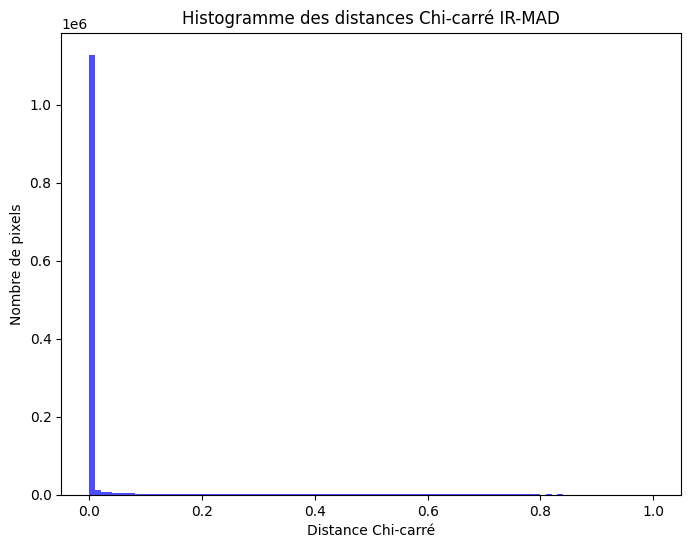

  Pixels détectés: 29930 (2.37%)


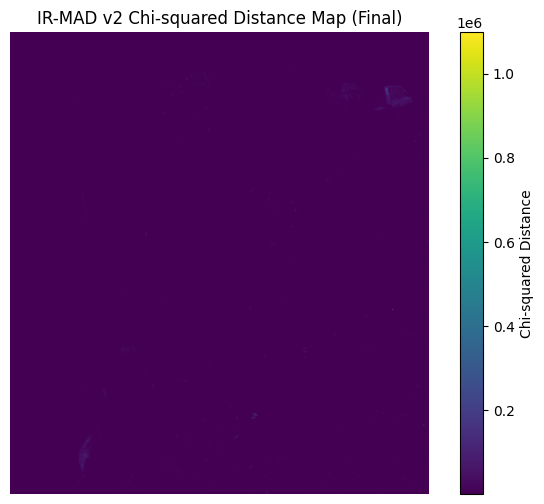

IR-MAD - Pixels détectés : 29930 (2.37%)
IR-MAD - F1-Score: 0.5621, Precision: 0.5995, Recall: 0.5290


In [13]:
# Perform IRMAD v2 detection
irmad_v2 = IRMAD(niter=10)
irmad_result = irmad_v2.detect(img1, img2, verbose=True, threshold_percentage=95)

# Visualize IR-MAD v2 chi2 distribution
plt.figure(figsize=(8, 6))
plt.imshow(irmad_v2.chi2_dist, cmap='viridis')
plt.colorbar(label='Chi-squared Distance')
plt.title('IR-MAD v2 Chi-squared Distance Map (Final)')
plt.axis('off')
plt.show()

# Print results
print(f"IR-MAD - Pixels détectés : {irmad_result.sum()} ({100*irmad_result.sum()/irmad_result.size:.2f}%)")

# Calcul des métriques
f1 = f1_score(ground_truth.flatten(), irmad_result.flatten())
precision = precision_score(ground_truth.flatten(), irmad_result.flatten())
recall = recall_score(ground_truth.flatten(), irmad_result.flatten())
print(f"IR-MAD - F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

## 7. Algorithme 4 : SiROC (Sibling Regression for Optical Change)

In [28]:
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import opening, closing, disk, remove_small_objects
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import HuberRegressor


class SiROC:
    """
    Practical SiROC implementation for OSCD
    - Spectral sibling regression
    - Robust (Huber) regression
    - Low-order polynomial ensemble
    - Raw difference accumulation
    """

    def __init__(self, s=1, n_max=4, min_area=25):
        """
        s      : step size for polynomial degree
        n_max  : maximum polynomial degree (recommended <= 4)
        """
        self.s = s
        self.n_max = n_max
        self.min_area = min_area
        self.uncertainty_map = None

    @staticmethod
    def _normalize(img):
        """Per-band normalization"""
        img = img.astype(np.float32)
        for b in range(img.shape[2]):
            mu = img[:, :, b].mean()
            std = img[:, :, b].std() + 1e-6
            img[:, :, b] = (img[:, :, b] - mu) / std
        return img

    def _apply_hsr(self, I_t, I_t1, degree):
        """Polynomial sibling regression per band"""
        H, W, B = I_t.shape
        I_hat = np.zeros_like(I_t)

        for b in range(B):
            x = I_t[:, :, b].reshape(-1, 1)
            y = I_t1[:, :, b].reshape(-1)

            poly = PolynomialFeatures(degree=degree, include_bias=True)
            X_poly = poly.fit_transform(x)

            reg = HuberRegressor(
                epsilon=1.35,
                alpha=0.0,
                max_iter=200
            )
            reg.fit(X_poly, y)

            y_hat = reg.predict(X_poly)
            I_hat[:, :, b] = y_hat.reshape(H, W)

        return I_hat

    def detect(self, img1, img2):
        """
        Full SiROC pipeline
        """
        # --- Normalize inputs ---
        img1 = self._normalize(img1)
        img2 = self._normalize(img2)

        H, W, _ = img1.shape
        self.uncertainty_map = np.zeros((H, W), dtype=np.float32)

        # --- Ensemble over polynomial degrees ---
        for degree in range(1, self.n_max, self.s):
            I_hat = self._apply_hsr(img1, img2, degree)

            # Raw spectral difference (NO threshold here)
            diff = np.sum(np.abs(I_hat - img2), axis=2)

            # Accumulate uncertainty
            self.uncertainty_map += diff

        # --- Final thresholding ---
        th = threshold_otsu(self.uncertainty_map)
        change_map = (self.uncertainty_map > th)

        # --- Morphological cleanup ---
        se = disk(1)
        change_map = opening(change_map, se)
        change_map = closing(change_map, se)
        change_map = remove_small_objects(change_map, self.min_area)

        return change_map.astype(np.uint8)


In [29]:
# Perform SiROC detection
siroc = SiROC(s=1, n_max=4, min_area=25)
siroc_result = siroc.detect(img1, img2)

# Print results
print(f"SiROC - Pixels détectés : {siroc_result.sum()} ({100*siroc_result.sum()/siroc_result.size:.2f}%)")    

# Calcul des métriques
f1 = f1_score(ground_truth.flatten(), siroc_result.flatten())
precision = precision_score(ground_truth.flatten(), siroc_result.flatten())
recall = recall_score(ground_truth.flatten(), siroc_result.flatten())
print(f"SiROC - F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

SiROC - Pixels détectés : 16420 (1.30%)
SiROC - F1-Score: 0.5309, Precision: 0.8138, Recall: 0.3940


## 8. Régularisation Spatiale : Graph Cuts (MRF)

In [17]:
def graph_cut_mrf_regularization(chi2_map: np.ndarray, threshold: float, beta: float = 1.0) -> np.ndarray:
    """
    Régularisation MRF par Graph Cuts basée sur l'énergie de Markov.
    Implémentation fidèle à la méthode proposée dans l'autre code.
    
    Args:
        chi2_map: Carte de distance Chi² IR-MAD [H, W]
        threshold: Seuil de séparation change/non-change (valeur chi²)
        beta: Poids du terme de régularisation spatiale (smoothness)
              Plus beta est élevé, plus le résultat est lisse
    
    Returns:
        Carte binaire de changement (1 = changement, 0 = non-changement)
    
    Principe:
        Minimise l'énergie E = E_data + E_smooth où:
        - E_data: pénalise les pixels mal classés selon leur valeur chi²
        - E_smooth: pénalise les discontinuités spatiales (favorise homogénéité)
    """
    import maxflow
    
    # Paramètres du modèle d'énergie
    E_max = 10.0          # Énergie maximale pour éviter divergence
    alpha = 0.0000001     # Contrôle la largeur de la zone d'incertitude
    
    # Seuils adaptatifs autour du threshold
    mu_s = threshold + (1.0 / alpha) ** 0.5  # centre de la classe "changement"
    mu_t = threshold - (1.0 / alpha) ** 0.5  # centre de la classe "non-changement"
    
    # 1. Terme de données (Unary Energy)    
    E_source = alpha * (mu_s - chi2_map) ** 2 # Énergie pour label "changement" (Source)
    E_source = np.clip(E_source, 0, E_max)
    E_source[chi2_map > mu_s] = 0 # Pas de pénalité si chi² déjà très élevé (évidence de changement)
    
    E_sink = alpha * (mu_t - chi2_map) ** 2 # Énergie pour label "non-changement" (Sink)
    E_sink = np.clip(E_sink, 0, E_max)
    E_sink[chi2_map < mu_t] = 0 # Pas de pénalité si chi² déjà très faible (évidence de non-changement)
    
    # 2. Construction du graphe
    g = maxflow.Graph[float]()
    nodeids = g.add_grid_nodes(chi2_map.shape)
    
    # T-links: connexions terminales (Source/Sink)
    g.add_grid_tedges(nodeids, E_sink, E_source)
    
    # N-links: connexions entre voisins (4-connecté)
    g.add_grid_edges(nodeids, beta) # beta contrôle la force de la régularisation spatiale
    
    # 3. Optimisation par Max-Flow / Min-Cut
    g.maxflow()
    
    # Récupérer la segmentation
    segments = g.get_grid_segments(nodeids)
    
    # Inverser: 1 = changement, 0 = non-changement
    change_map = np.logical_not(segments).astype(np.uint8)

    change_map = filter_by_area(change_map, min_area_pixels=100, max_area_pixels=50000)
    
    return change_map


def visualize_mrf_energy_functions(threshold: float, alpha: float = 0.0000001):
    """
    Visualise les fonctions d'énergie utilisées dans le MRF.
    Utile pour comprendre comment le modèle classe les pixels.
    """
    E_max = 10.0
    mu_s = threshold + (1.0 / alpha) ** 0.5
    mu_t = threshold - (1.0 / alpha) ** 0.5
    
    # Plage de valeurs chi²
    x = np.linspace(0, threshold * 2, 1000)
    
    # Énergies pour chaque label
    E_source = alpha * (mu_s - x) ** 2
    E_source = np.clip(E_source, 0, E_max)
    E_source[x > mu_s] = 0
    
    E_sink = alpha * (mu_t - x) ** 2
    E_sink = np.clip(E_sink, 0, E_max)
    E_sink[x < mu_t] = 0
    
    plt.figure(figsize=(12, 5))
    plt.plot(x, E_sink, 'b-', linewidth=2, label='E(non-changement)')
    plt.plot(x, E_source, 'r-', linewidth=2, label='E(changement)')
    plt.axvline(threshold, color='green', linestyle='--', linewidth=2, label=f'Seuil = {threshold:.1f}')
    plt.axvline(mu_t, color='cyan', linestyle=':', alpha=0.7, label=f'μ_t = {mu_t:.1f}')
    plt.axvline(mu_s, color='orange', linestyle=':', alpha=0.7, label=f'μ_s = {mu_s:.1f}')
    plt.xlabel('Valeur Chi² du pixel')
    plt.ylabel('Énergie (coût)')
    plt.title('Fonctions d\'énergie du MRF - Terme de données')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.5, E_max + 1)
    plt.show()

Test de régularisation MRF avec différents paramètres de lissage (beta):



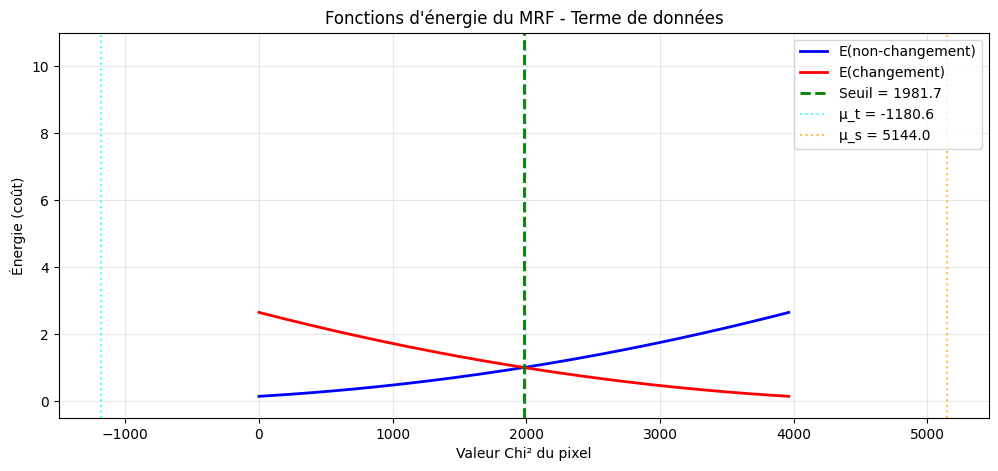

→ Beta = 0.1
  Pixels détectés: 27292 (2.16%)
  F1=0.5299, Precision=0.5943, Recall=0.4782

→ Beta = 1.0
  Pixels détectés: 26403 (2.09%)
  F1=0.5493, Precision=0.6275, Recall=0.4885

→ Beta = 5.0
  Pixels détectés: 28948 (2.29%)
  F1=0.5691, Precision=0.6180, Recall=0.5274

→ Beta = 10.0
  Pixels détectés: 22660 (1.79%)
  F1=0.5924, Precision=0.7395, Recall=0.4940



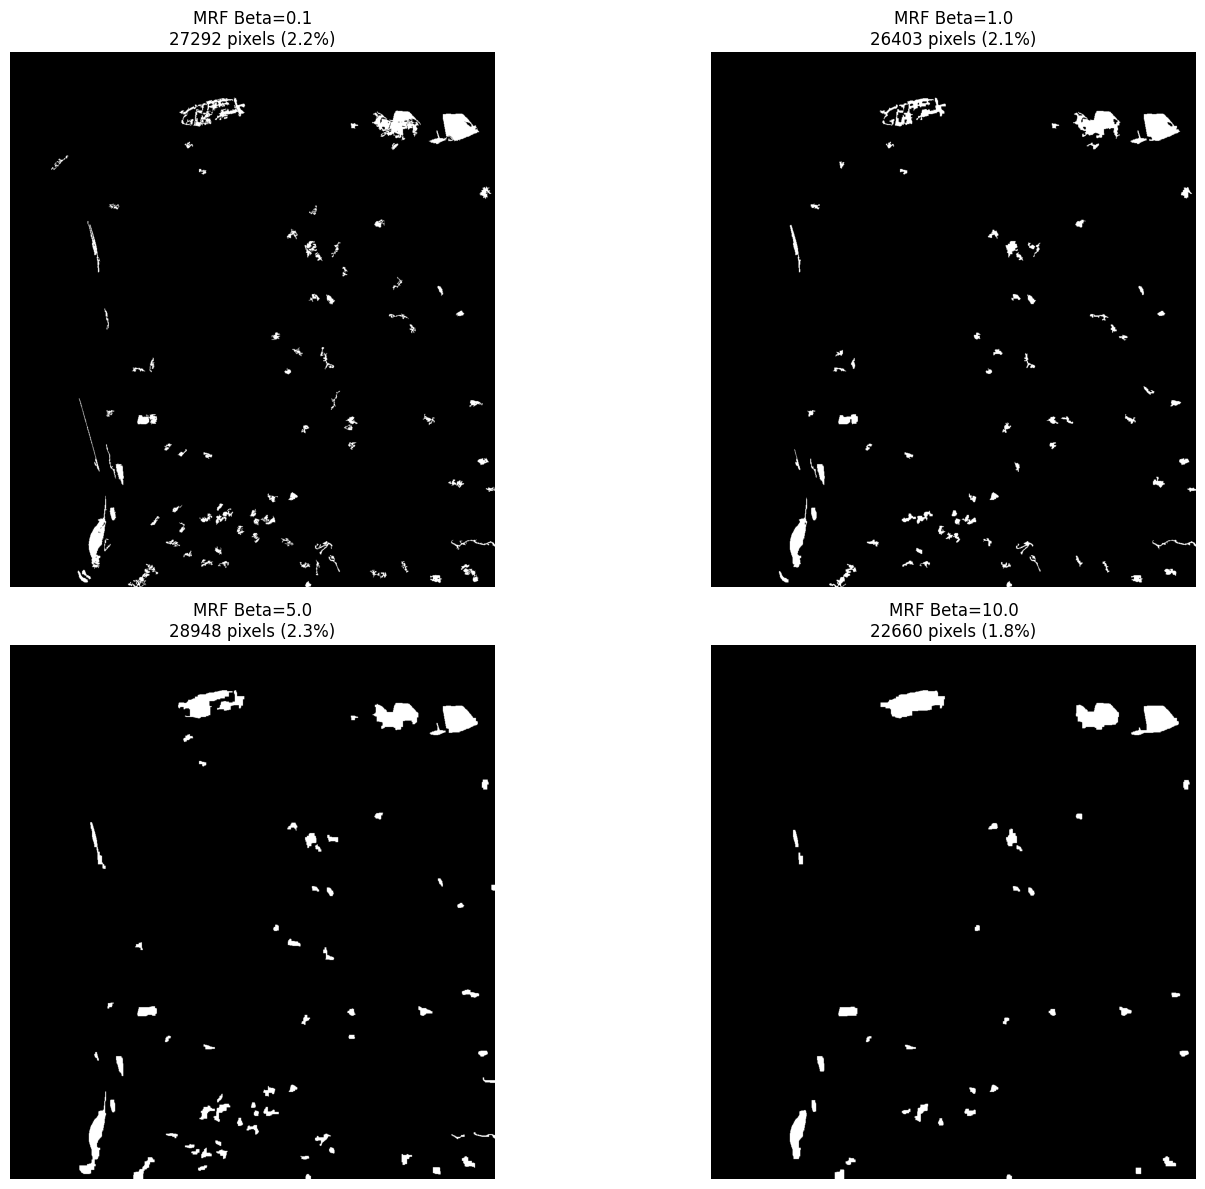

In [18]:
print("Test de régularisation MRF avec différents paramètres de lissage (beta):\n")

# Déterminer un seuil raisonnable (95e percentile)
threshold = np.percentile(irmad_v2.chi2_dist, 90)

# Visualiser les fonctions d'énergie
visualize_mrf_energy_functions(threshold)

# Tester différentes valeurs de beta
beta_values = [0.1, 1.0, 5.0, 10.0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, beta in enumerate(beta_values):
    print(f"→ Beta = {beta}")
    mrf_result = graph_cut_mrf_regularization(irmad_v2.chi2_dist, threshold, beta)
    n_changes = mrf_result.sum()
    pct_changes = 100 * n_changes / mrf_result.size
    
    print(f"  Pixels détectés: {n_changes} ({pct_changes:.2f}%)")
    
    # Calcul des métriques si ground truth disponible
    if 'ground_truth' in locals():
        from sklearn.metrics import f1_score, precision_score, recall_score
        f1 = f1_score(ground_truth.flatten(), mrf_result.flatten())
        precision = precision_score(ground_truth.flatten(), mrf_result.flatten())
        recall = recall_score(ground_truth.flatten(), mrf_result.flatten())
        print(f"  F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}\n")
    
    # Visualisation
    axes[idx].imshow(mrf_result, cmap='gray')
    axes[idx].set_title(f'MRF Beta={beta}\n{n_changes} pixels ({pct_changes:.1f}%)')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [19]:
# Choisir la meilleure valeur de beta (par exemple beta=1.0)
print("\n" + "="*70)
print("Application du MRF avec beta optimal")
print("="*70)

threshold = np.percentile(irmad_v2.chi2_dist, 90)
irmad_mrf = graph_cut_mrf_regularization(irmad_v2.chi2_dist, threshold, beta=0.5)

if 'ground_truth' in locals():
    from sklearn.metrics import f1_score, precision_score, recall_score, cohen_kappa_score
    metrics = {
        'F1-Score': f1_score(ground_truth.flatten(), irmad_mrf.flatten()),
        'Precision': precision_score(ground_truth.flatten(), irmad_mrf.flatten()),
        'Recall': recall_score(ground_truth.flatten(), irmad_mrf.flatten()),
        'Kappa': cohen_kappa_score(ground_truth.flatten(), irmad_mrf.flatten())
    }
    
    print(f"F1-Score  : {metrics['F1-Score']:.4f}")
    print(f"Precision : {metrics['Precision']:.4f}")
    print(f"Recall    : {metrics['Recall']:.4f}")
    print(f"Kappa     : {metrics['Kappa']:.4f}")
else:
    print("Exécutez d'abord la cellule IR-MAD pour générer irmad_v2.chi2_dist")


Application du MRF avec beta optimal
F1-Score  : 0.5482
Precision : 0.6283
Recall    : 0.4862
Kappa     : 0.5373


## 9. Évaluation des Méthodes

In [20]:
def visualize_change_maps(ground_truth: np.ndarray, **change_maps):
    """
    Visualise les cartes de changement binaires produites par différents algorithmes.
    
    Args:
        ground_truth: Carte de changement de référence (binaire).
        change_maps: Dictionnaire contenant les cartes de changement binaires 
                     produites par les algorithmes (nom -> carte).
    """
    n_methods = len(change_maps)
    fig, axes = plt.subplots(n_methods + 1, 1, figsize=(6, 6 * (n_methods + 1)))
    
    # Afficher le ground truth
    axes[0].imshow(ground_truth * 255, cmap='gray')
    axes[0].set_title('Ground Truth')
    axes[0].axis('off')
    
    # Afficher les cartes de changement
    for i, (method_name, change_map) in enumerate(change_maps.items(), start=1):
        axes[i].imshow(change_map * 255, cmap='gray')
        axes[i].set_title(method_name)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

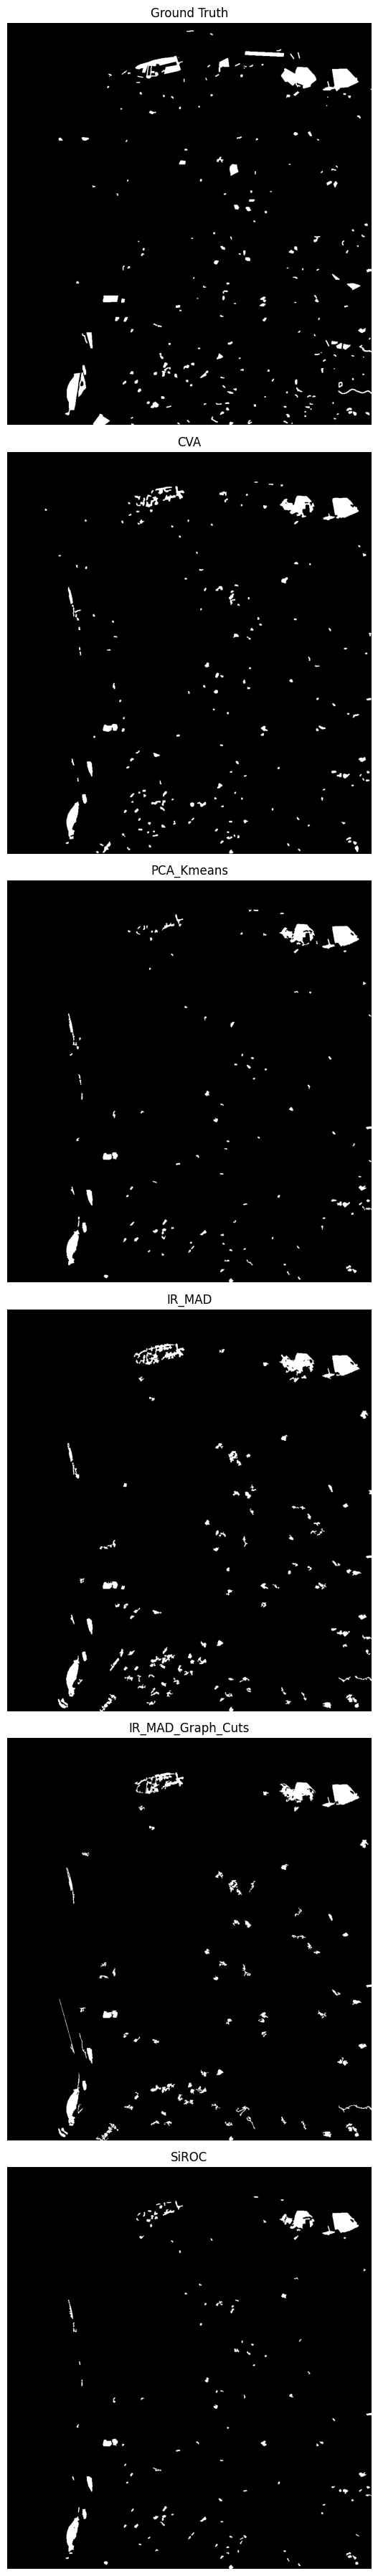

In [30]:
visualize_change_maps(
    ground_truth,
    CVA=cva_result,
    PCA_Kmeans=pca_kmeans_result,
    IR_MAD=irmad_result,
    IR_MAD_Graph_Cuts=irmad_mrf,
    SiROC=siroc_result
)

In [31]:
class ChangeDetectionEvaluator:
    """Évaluateur pour les méthodes de détection de changement."""
    
    @staticmethod
    def compute_metrics(pred: np.ndarray, gt: np.ndarray) -> Dict[str, float]:
        """Calcule les métriques de performance."""
        print("Shape de pred:", pred.shape)
        print("Shape de ground_truth:", gt.shape)
        pred_flat = pred.flatten()
        gt_flat = gt.flatten()
        
        metrics = {
            'Precision': precision_score(gt_flat, pred_flat, zero_division=0),
            'Recall': recall_score(gt_flat, pred_flat, zero_division=0),
            'F1-Score': f1_score(gt_flat, pred_flat, zero_division=0),
            'Kappa': cohen_kappa_score(gt_flat, pred_flat),
        }
        
        # Matrice de confusion
        tn, fp, fn, tp = confusion_matrix(gt_flat, pred_flat).ravel()
        metrics['TN'] = tn
        metrics['FP'] = fp
        metrics['FN'] = fn
        metrics['TP'] = tp
        
        return metrics
    
    @staticmethod
    def print_metrics(method_name: str, metrics: Dict[str, float]):
        """Affiche les métriques formatées."""
        print(f"\n{'='*50}")
        print(f"Méthode: {method_name}")
        print(f"{'='*50}")
        print(f"F1-Score  : {metrics['F1-Score']:.4f}")
        print(f"Precision : {metrics['Precision']:.4f}")
        print(f"Recall    : {metrics['Recall']:.4f}")
        print(f"Kappa     : {metrics['Kappa']:.4f}")
        print(f"TP: {metrics['TP']}, FP: {metrics['FP']}, FN: {metrics['FN']}, TN: {metrics['TN']}")

# Évaluation de toutes les méthodes
evaluator = ChangeDetectionEvaluator()

results = {
    'CVA': cva_result,
    'PCA-Kmeans': pca_kmeans_result,
    'IR-MAD': irmad_result,
    'IR-MAD + Graph Cuts': irmad_mrf,
    'SiROC': siroc_result
}

metrics_summary = {}
for method_name, prediction in results.items():
    metrics = evaluator.compute_metrics(prediction, ground_truth)
    metrics_summary[method_name] = metrics
    evaluator.print_metrics(method_name, metrics)

Shape de pred: (1180, 1070)
Shape de ground_truth: (1180, 1070)

Méthode: CVA
F1-Score  : 0.5782
Precision : 0.7104
Recall    : 0.4876
Kappa     : 0.5688
TP: 16537, FP: 6742, FN: 17381, TN: 1221940
Shape de pred: (1180, 1070)
Shape de ground_truth: (1180, 1070)

Méthode: PCA-Kmeans
F1-Score  : 0.5320
Precision : 0.7918
Recall    : 0.4006
Kappa     : 0.5234
TP: 13586, FP: 3572, FN: 20332, TN: 1225110
Shape de pred: (1180, 1070)
Shape de ground_truth: (1180, 1070)

Méthode: IR-MAD
F1-Score  : 0.5621
Precision : 0.5995
Recall    : 0.5290
Kappa     : 0.5507
TP: 17943, FP: 11987, FN: 15975, TN: 1216695
Shape de pred: (1180, 1070)
Shape de ground_truth: (1180, 1070)

Méthode: IR-MAD + Graph Cuts
F1-Score  : 0.5482
Precision : 0.6283
Recall    : 0.4862
Kappa     : 0.5373
TP: 16491, FP: 9758, FN: 17427, TN: 1218924
Shape de pred: (1180, 1070)
Shape de ground_truth: (1180, 1070)

Méthode: SiROC
F1-Score  : 0.5309
Precision : 0.8138
Recall    : 0.3940
Kappa     : 0.5226
TP: 13363, FP: 3057, FN: 

## 10. Pipeline de Traitement sur Toutes les Images

In [32]:
def process_all_locations(base_path: str, methods_to_run: List[str] = None):
    """
    Traite toutes les locations et calcule les métriques moyennes.
    
    Args:
        base_path: Chemin vers le dataset OSCD
        methods_to_run: Liste des méthodes à exécuter 
                       ['CVA', 'PCA-Kmeans', 'IR-MAD', 'IR-MAD+GC', 'SiROC']
    """
    if methods_to_run is None:
        # Par défaut, exclure SiROC (trop lent)
        methods_to_run = ['CVA', 'PCA-Kmeans', 'IR-MAD', 'IR-MAD+GC', 'SiROC']
    
    all_locations = OSCDDataLoader.get_all_locations(base_path)
    print(f"Traitement de {len(all_locations)} locations : {all_locations}")
    print(f"Méthodes sélectionnées : {methods_to_run}\n")
    
    # Stockage des résultats
    all_metrics = {method: [] for method in methods_to_run}
    evaluator = ChangeDetectionEvaluator()
    
    for idx, location in enumerate(all_locations):
        print(f"\n{'='*70}")
        print(f"[{idx+1}/{len(all_locations)}] Traitement de : {location}")
        print(f"{'='*70}")
        
        try:
            # Charger les données
            loader = OSCDDataLoader(base_path, location)
            img1, img2, ground_truth = loader.load_data(feature_mode="raw")
            
            results_location = {}
            
            # CVA
            if 'CVA' in methods_to_run:
                print("\n→ CVA...")
                cva = CVA()
                results_location['CVA'] = cva.detect(img1, img2)
            
            # PCA-Kmeans
            if 'PCA-Kmeans' in methods_to_run:
                print("\n→ PCA-Kmeans...")
                pca_kmeans = PCAKmeans(n_components=2)
                results_location['PCA-Kmeans'] = pca_kmeans.detect(img1, img2)
            
            # IR-MAD
            if 'IR-MAD' in methods_to_run:
                print("\n→ IR-MAD...")
                irmad = IRMAD(niter=10)
                results_location['IR-MAD'] = irmad.detect(img1, img2, verbose=False, threshold_percentage=96, use_maf=True)
            
            # IR-MAD + Graph Cuts
            if 'IR-MAD+GC' in methods_to_run and 'IR-MAD' in methods_to_run:
                print("\n→ IR-MAD + Graph Cuts...")
                irmad = IRMAD(niter=10)
                _ = irmad.detect(img1, img2, verbose=False, threshold_percentage=95, use_maf=False)
                results_location['IR-MAD+GC'] = graph_cut_mrf_regularization(
                    irmad.chi2_dist, 
                    threshold=np.percentile(irmad.chi2_dist, 90), 
                    beta=0.5
                )
            
            # SiROC
            if 'SiROC' in methods_to_run:
                print("\n→ SiROC (peut prendre plusieurs minutes)...")
                siroc = SiROC(s=1, n_max=4, min_area=25)
                results_location['SiROC'] = siroc.detect(img1, img2)
            
            # Calculer les métriques pour cette location
            print("\n→ Calcul des métriques...")
            for method_name, prediction in results_location.items():
                metrics = evaluator.compute_metrics(prediction, ground_truth)
                all_metrics[method_name].append(metrics)
                print(f"  {method_name}: F1={metrics['F1-Score']:.4f}, "
                      f"Precision={metrics['Precision']:.4f}, "
                      f"Recall={metrics['Recall']:.4f}")
        
        except Exception as e:
            print(f"❌ Erreur lors du traitement de {location}: {str(e)}")
            continue
    
    return all_metrics, all_locations

all_metrics, processed_locations = process_all_locations(
    base_path, 
    methods_to_run=['CVA', 'PCA-Kmeans', 'IR-MAD', 'IR-MAD+GC', 'SiROC']
)

Traitement de 24 locations : ['abudhabi', 'aguasclaras', 'beihai', 'beirut', 'bercy', 'bordeaux', 'brasilia', 'chongqing', 'cupertino', 'dubai', 'hongkong', 'lasvegas', 'milano', 'montpellier', 'mumbai', 'nantes', 'norcia', 'paris', 'pisa', 'rennes', 'rio', 'saclay_e', 'saclay_w', 'valencia']
Méthodes sélectionnées : ['CVA', 'PCA-Kmeans', 'IR-MAD', 'IR-MAD+GC', 'SiROC']


[1/24] Traitement de : abudhabi
Chargement depuis OSCD\abudhabi...
✓ Image 1 : (799, 785, 9), Image 2 : (799, 785, 9)
Feature mode : raw
✓ Label : (799, 785), Pixels changés : 23592 (3.76%)

→ CVA...

→ PCA-Kmeans...

→ IR-MAD...

→ IR-MAD + Graph Cuts...

→ SiROC (peut prendre plusieurs minutes)...

→ Calcul des métriques...
Shape de pred: (799, 785)
Shape de ground_truth: (799, 785)
  CVA: F1=0.3015, Precision=0.3964, Recall=0.2433
Shape de pred: (799, 785)
Shape de ground_truth: (799, 785)
  PCA-Kmeans: F1=0.1124, Precision=0.0611, Recall=0.6964
Shape de pred: (799, 785)
Shape de ground_truth: (799, 785)
  IR-MAD: 

## 11. Analyse Globale des Résultats

In [33]:
import pandas as pd

def compute_aggregate_metrics(all_metrics: Dict[str, List[Dict]]) -> pd.DataFrame:
    """Calcule les statistiques agrégées (moyenne, écart-type) pour chaque méthode."""
    summary = {}
    
    for method_name, metrics_list in all_metrics.items():
        if len(metrics_list) == 0:
            continue
        
        # Extraire les métriques numériques
        f1_scores = [m['F1-Score'] for m in metrics_list]
        precisions = [m['Precision'] for m in metrics_list]
        recalls = [m['Recall'] for m in metrics_list]
        kappas = [m['Kappa'] for m in metrics_list]
        
        summary[method_name] = {
            'F1-Score (mean)': np.mean(f1_scores),
            'F1-Score (std)': np.std(f1_scores),
            'Precision (mean)': np.mean(precisions),
            'Precision (std)': np.std(precisions),
            'Recall (mean)': np.mean(recalls),
            'Recall (std)': np.std(recalls),
            'Kappa (mean)': np.mean(kappas),
            'Kappa (std)': np.std(kappas),
            'N images': len(metrics_list)
        }
    
    df = pd.DataFrame(summary).T
    return df

# Calculer et afficher les résultats agrégés
df_summary = compute_aggregate_metrics(all_metrics)

print("\n" + "="*100)
print("RÉSULTATS AGRÉGÉS SUR TOUTES LES IMAGES")
print("="*100)
print(df_summary.to_string())
print("="*100)


RÉSULTATS AGRÉGÉS SUR TOUTES LES IMAGES
            F1-Score (mean)  F1-Score (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  Kappa (mean)  Kappa (std)  N images
CVA                0.334283        0.201852          0.340629         0.218909       0.395711      0.207311      0.317413     0.198878      24.0
PCA-Kmeans         0.140858        0.188492          0.150599         0.248648       0.407723      0.189992      0.105752     0.189452      24.0
IR-MAD             0.307916        0.164527          0.403485         0.277048       0.301785      0.132326      0.294050     0.163244      24.0
IR-MAD+GC          0.327829        0.197278          0.337216         0.234167       0.379725      0.189009      0.310810     0.195791      24.0
SiROC              0.276426        0.209885          0.272846         0.249130       0.455356      0.181871      0.254520     0.205111      24.0


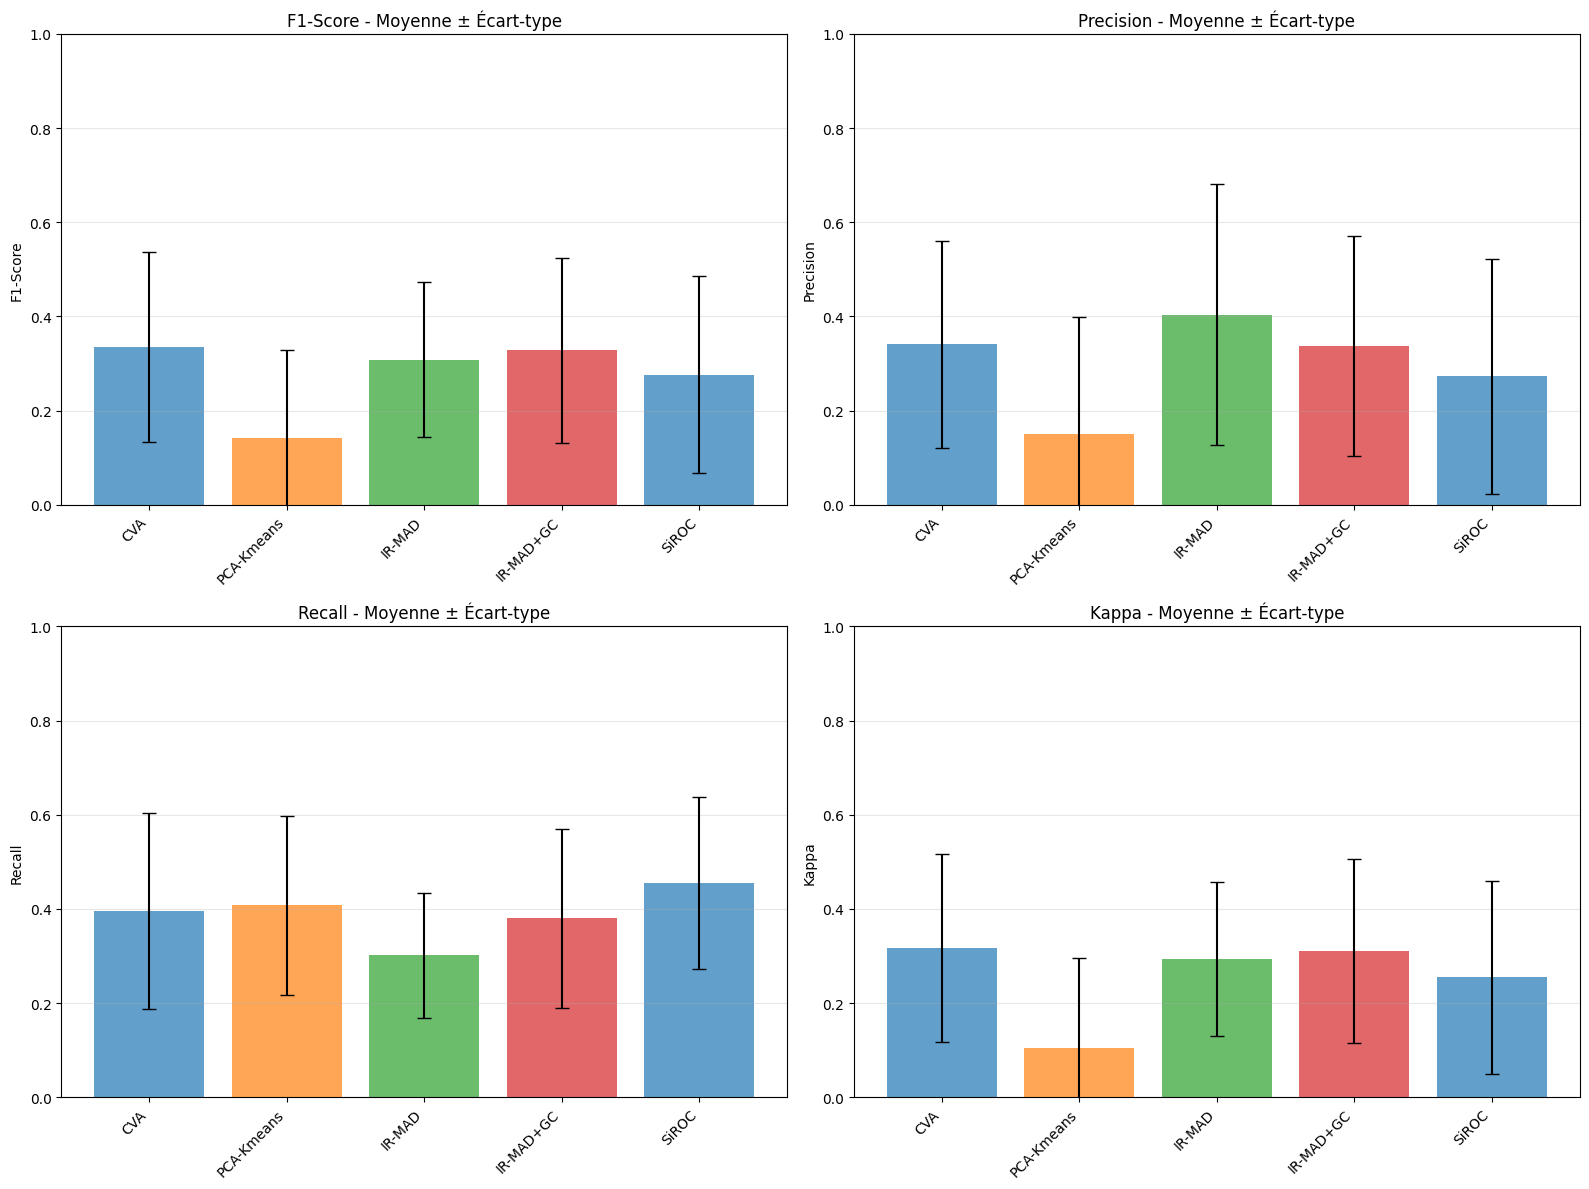

In [34]:
# Graphique comparatif avec barres d'erreur
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_names = ['F1-Score', 'Precision', 'Recall', 'Kappa']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics_names):
    ax = axes_flat[idx]
    
    means = df_summary[f'{metric} (mean)'].values
    stds = df_summary[f'{metric} (std)'].values
    methods = df_summary.index.tolist()
    
    x_pos = np.arange(len(methods))
    ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, 
           color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(methods)])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} - Moyenne ± Écart-type')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 12. Résultats Détaillés par Location

In [35]:
# Créer un DataFrame détaillé avec toutes les locations
detailed_results = []

for method_name, metrics_list in all_metrics.items():
    for idx, metrics in enumerate(metrics_list):
        detailed_results.append({
            'Location': processed_locations[idx],
            'Method': method_name,
            'F1-Score': metrics['F1-Score'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'Kappa': metrics['Kappa']
        })

df_detailed = pd.DataFrame(detailed_results)

# Afficher le top 5 et bottom 5 pour chaque méthode (basé sur F1-Score)
print("\n" + "="*100)
print("MEILLEURES ET PIRES PERFORMANCES PAR MÉTHODE")
print("="*100)

for method in df_detailed['Method'].unique():
    df_method = df_detailed[df_detailed['Method'] == method].sort_values('F1-Score', ascending=False)
    print(f"\n{method}:")
    print("  Top 3:")
    print(df_method.head(3)[['Location', 'F1-Score', 'Precision', 'Recall']].to_string(index=False))
    print("  Bottom 3:")
    print(df_method.tail(3)[['Location', 'F1-Score', 'Precision', 'Recall']].to_string(index=False))


MEILLEURES ET PIRES PERFORMANCES PAR MÉTHODE

CVA:
  Top 3:
   Location  F1-Score  Precision   Recall
   lasvegas  0.684655   0.688617 0.680738
montpellier  0.678764   0.635901 0.727823
     beirut  0.578247   0.710383 0.487558
  Bottom 3:
Location  F1-Score  Precision   Recall
bordeaux  0.064109   0.036594 0.258403
saclay_w  0.040139   0.038908 0.041451
valencia  0.016355   0.009446 0.060888

PCA-Kmeans:
  Top 3:
   Location  F1-Score  Precision   Recall
   lasvegas  0.647822   0.760518 0.564215
montpellier  0.550695   0.609865 0.501992
     beirut  0.531992   0.791817 0.400554
  Bottom 3:
Location  F1-Score  Precision   Recall
  norcia  0.016937   0.008783 0.236349
valencia  0.009660   0.004878 0.489164
  rennes  0.000000   0.000000 0.000000

IR-MAD:
  Top 3:
   Location  F1-Score  Precision   Recall
   brasilia  0.563328   0.720571 0.462419
   lasvegas  0.523483   0.906657 0.367970
montpellier  0.523378   0.858491 0.376436
  Bottom 3:
Location  F1-Score  Precision   Recall
   paris

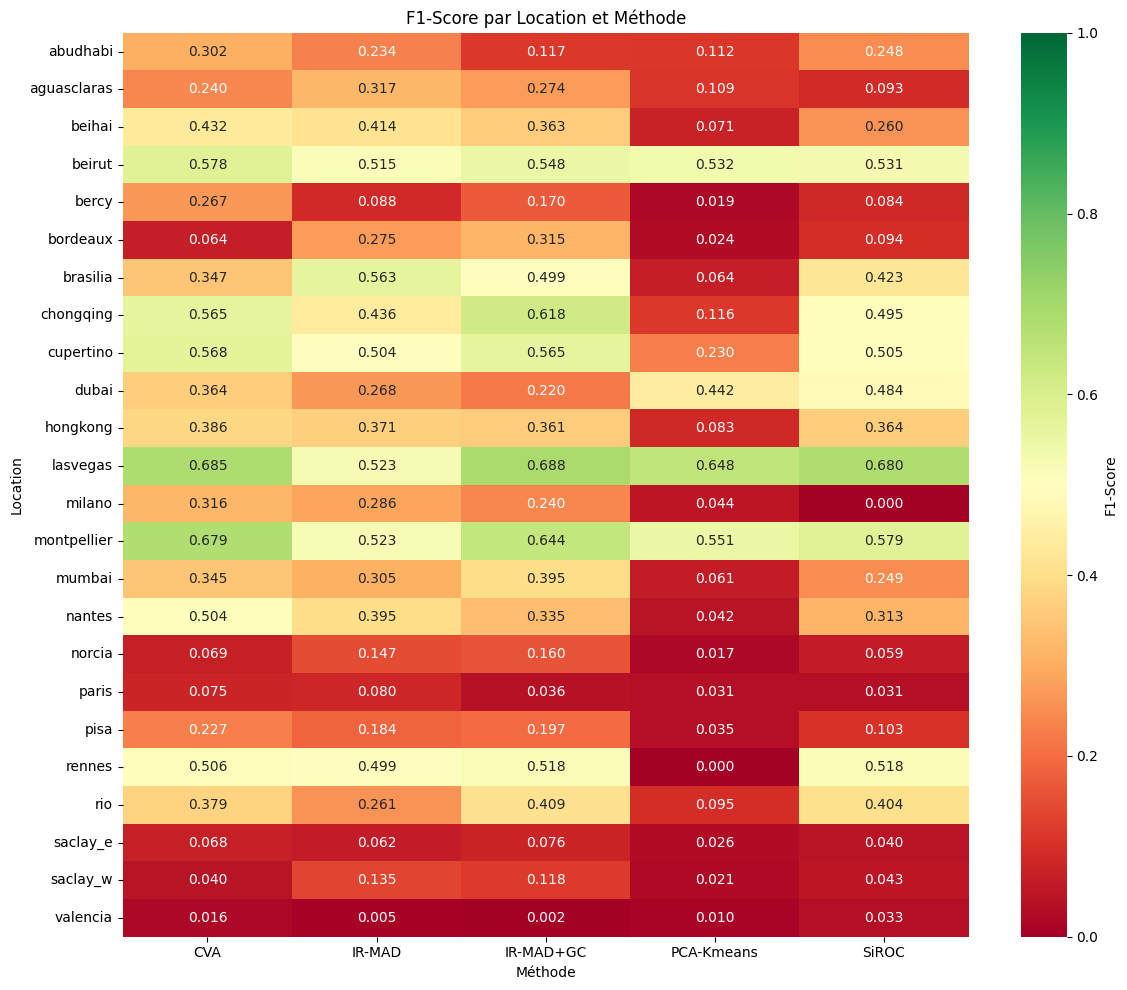

In [36]:
# Heatmap des performances par location et méthode
import matplotlib.pyplot as plt
import seaborn as sns

pivot_f1 = df_detailed.pivot(index='Location', columns='Method', values='F1-Score')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, 
            cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score par Location et Méthode')
plt.xlabel('Méthode')
plt.ylabel('Location')
plt.tight_layout()
plt.show()